In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import time
import numpy as np
data = pd.read_csv('../../data/Housing.csv')

print(data.size)

X1 = data['area'].values
X2 = data['bedrooms'].values
X3 = data['bathrooms'].values
X4 = data['age'].values

y = data['price'].values


X1_train, X1_test, X2_train, X2_test, X3_train, X3_test, X4_train, X4_test, y_train, y_test = train_test_split(
    X1, X2, X3, X4, y, test_size=0.1, random_state=42
)
def normalize(arr):
    return (arr - arr.min()) / (arr.max() - arr.min())
  

# NORMAILZE
X1_train = normalize(X1_train)
X1_test = normalize(X1_test)

X2_train = normalize(X2_train)
X2_test = normalize(X2_test)

X3_train = normalize(X3_train)
X3_test = normalize(X3_test)

X4_train = normalize(X4_train)
X4_test = normalize(X4_test)

y_train = normalize(y_train)
y_test = normalize(y_test)

print(X1_train[:5])
print(X1_test[:5])

print(X2_train[:5])
print(X2_test[:5])

print(X3_train[:5])
print(X3_test[:5])

print(X4_train[:5])
print(X4_test[:5])

print(y_train[:5])
print(y_test[:5])


94981
[0.28634949 0.8921743  0.5222321  0.02823477 0.00177857]
[0.68911686 0.44090098 0.05508475 0.3719893  0.51092774]
[0.4 1.  0.6 0.2 0.6]
[0.8 0.6 0.  1.  0.8]
[0.33333333 0.66666667 0.         0.         0.33333333]
[0.66666667 1.         0.66666667 1.         0.        ]
[0.35897436 0.05128205 0.23076923 0.58974359 0.82051282]
[0.74358974 0.38461538 0.58974359 0.23076923 0.05128205]
[0.31069471 0.84757693 0.52295643 0.03754057 0.09725749]
[0.69939106 0.47821536 0.01667502 0.35771184 0.51378737]


In [17]:
features = np.array((X1_train , X2_train , X3_train , X4_train , np.ones(len(X1_train)))).T
print(features.shape)

parameters = np.array([0, 0 , 0 , 0 , 0])
print(parameters.shape)

(4499, 5)
(5,)


In [18]:
from sklearn.metrics import r2_score
learning_rate = 0.1
epochs = 1000
losses = []
start_time = time.perf_counter()
for i in range(epochs):
    y_pred = np.dot(features , parameters)
    n = len(X1_train)

    loss = np.mean((y_train - y_pred) ** 2)

    losses.append(loss)
    gradient = (2/n) * np.dot(features.T, (y_pred - y_train))
    
    parameters = parameters - (learning_rate * gradient)

end_time = time.perf_counter()
print(f"Loop execution time: {end_time - start_time:.6f} seconds")
loss = np.mean((y_train - y_pred) ** 2)
y_pred = np.dot(features , parameters)
print(loss)
print(parameters)

print("R2 Score:", r2_score(y_train, y_pred))

# Interpreting R2 Score:
# R2 = 1: Perfect fit. The model explains all the variability in the target variable.
# R2 = 0: The model does not explain any variability in the target variable.
# 0 < R2 < 1: The model explains a proportion of the variability in the target variable.
# A higher R2 score indicates a better fit,


Loop execution time: 0.045090 seconds
0.000669713329006155
[ 0.87131157  0.03323852  0.01317527 -0.05437486  0.06496657]
R2 Score: 0.9894619036652946


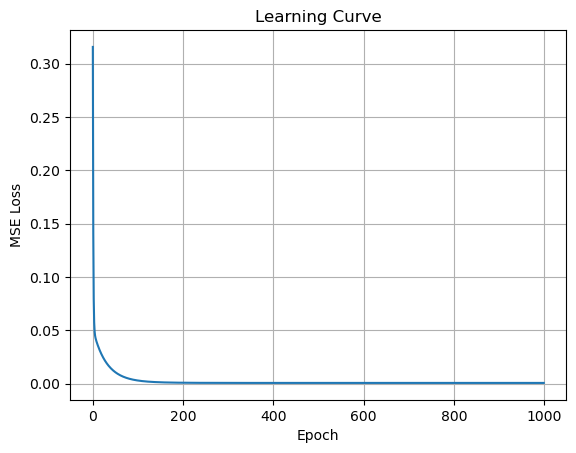

In [19]:
# learning curve Epochs vs Loss

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Learning Curve")
plt.grid(True)
plt.show()

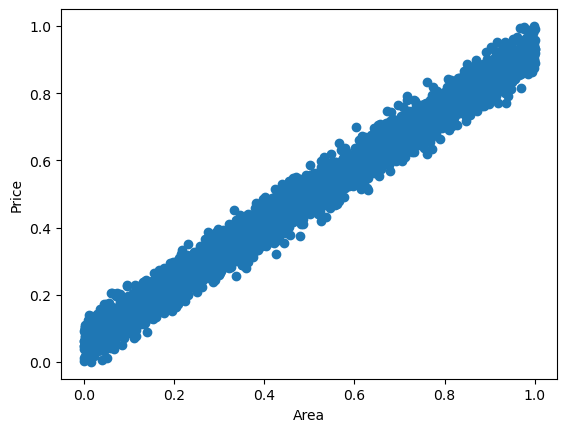

In [20]:
plt.scatter(X1_train, y_train)
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

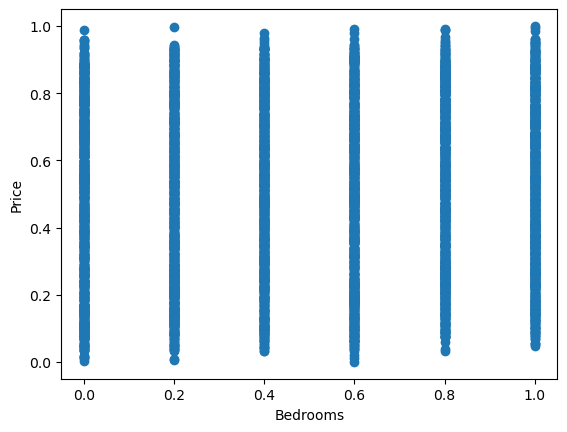

In [21]:
plt.scatter(X2_train, y_train)
plt.xlabel("Bedrooms")
plt.ylabel("Price")
plt.show()

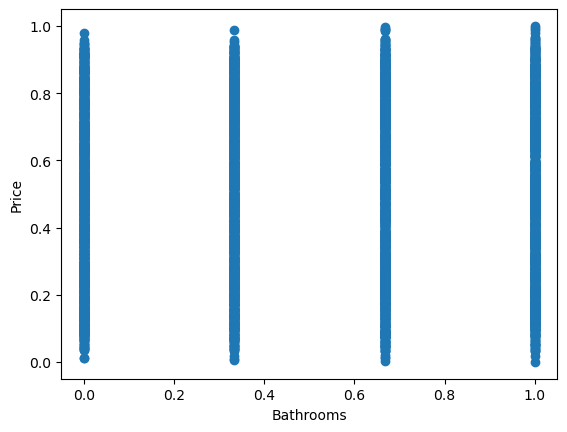

In [22]:
plt.scatter(X3_train, y_train)

plt.xlabel("Bathrooms")
plt.ylabel("Price")
plt.show()

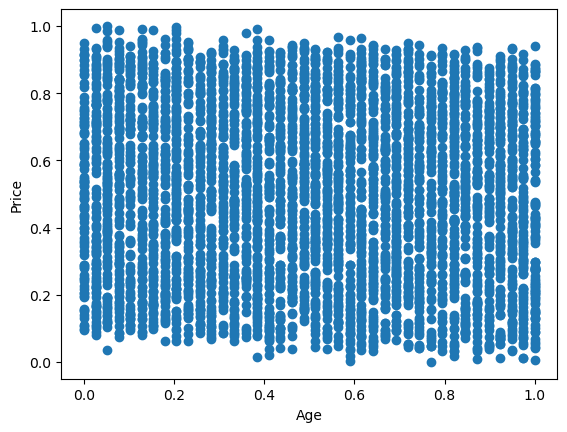

In [23]:
plt.scatter(X4_train, y_train)
plt.xlabel("Age")
plt.ylabel("Price")
plt.show()

In [ ]:
features = np.array((X1_test , X2_test , X3_test , X4_test , np.ones(len(X1_test)))).T
print(features.shape)


(500, 5)
(5,)


In [ ]:

plt.scatter(X_test,y_test)

plt.plot(X_test, y_pred , color = 'red')

plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

Loop execution time: 0.008963 seconds
0.0007605600105165366
[ 0.90647392  0.03561655  0.00943214 -0.05063761  0.04921718]
R2 Score: 0.9879615918478614
